# Historical Air Quality Analysis — AirQualityUCI

**Dataset:** UCI Air Quality (De Vito et al.) — hourly measurements from a multisensor device deployed in an Italian city, March 2004 – April 2005.

**Goal:** explore pollutant trends, quantify pollutant–weather relationships, and build a simple predictive model for benzene.

**Tools:** pandas · matplotlib · seaborn · scikit-learn

## 1 · Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

## 2 · Load and inspect

The CSV uses **semicolons** as separators, **commas** as decimal points, and **−200** as the missing-value sentinel. The file also has two stray empty trailing columns and ~100 blank rows at the end.

In [ ]:
SRC = "../data/raw/AirQualityUCI.csv"

df = pd.read_csv(SRC, sep=";", decimal=",", na_values=["-200", "-200,0"])
df = df.loc[:, ~df.columns.str.match(r"^Unnamed")]
df = df.dropna(how="all").reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 3 · Clean: replace remaining sentinels, build datetime index, rename columns

In [ ]:
# Replace any -200 still hiding (some columns may sneak through with float dtype)
df = df.replace(-200, np.nan)

# Build a proper Datetime index
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
)
df = df.drop(columns=["Date", "Time"]).set_index("Datetime").sort_index()

# Friendly column names
RENAME = {
    "CO(GT)": "CO_mgm3", "PT08.S1(CO)": "S1_CO",
    "NMHC(GT)": "NMHC_ugm3", "C6H6(GT)": "C6H6_ugm3",
    "PT08.S2(NMHC)": "S2_NMHC", "NOx(GT)": "NOx_ppb",
    "PT08.S3(NOx)": "S3_NOx", "NO2(GT)": "NO2_ugm3",
    "PT08.S4(NO2)": "S4_NO2", "PT08.S5(O3)": "S5_O3",
    "T": "Temp_C", "RH": "RH_pct", "AH": "AbsHum",
}
df = df.rename(columns=RENAME)

print("Period:", df.index.min(), "→", df.index.max())
print("\nMissing % per column:")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

Period: 2004-03-10 18:00:00 → 2005-04-04 14:00:00

Missing % per column:
NMHC_ugm3    90.2
CO_mgm3      18.0
NOx_ppb      17.5
NO2_ugm3     17.5
S1_CO         3.9
S2_NMHC       3.9
C6H6_ugm3     3.9
S3_NOx        3.9
S4_NO2        3.9
S5_O3         3.9
Temp_C        3.9
RH_pct        3.9
AbsHum        3.9
dtype: float64


NMHC is >90% missing and is therefore excluded. Time-based interpolation is applied with a six-observation limit in each direction, while unresolved missing values are retained.

In [ ]:
# Drop NMHC because more than 90% of its observations are missing
df = df.drop(columns=["NMHC_ugm3"])

POLLUTANTS = ["CO_mgm3", "C6H6_ugm3", "NOx_ppb", "NO2_ugm3"]
WEATHER    = ["Temp_C", "RH_pct", "AbsHum"]
ANALYSIS_VARS = POLLUTANTS + WEATHER

# Record missing values before interpolation
missing_before = df[ANALYSIS_VARS].isna().sum()

# Apply time-based interpolation with a six-observation limit in each direction
df_clean = df.interpolate(
    method="time",
    limit=6,
    limit_direction="both"
)

# Compare missingness before and after interpolation
missing_after = df_clean[ANALYSIS_VARS].isna().sum()

missing_summary = pd.DataFrame({
    "Missing before": missing_before,
    "Missing after": missing_after,
    "Values filled": missing_before - missing_after
})

missing_summary

,Missing before,Missing after,Values filled
CO_mgm3,1683,1181,502
C6H6_ugm3,366,240,126
NOx_ppb,1639,1062,577
NO2_ugm3,1642,1064,578
Temp_C,366,240,126
RH_pct,366,240,126
AbsHum,366,240,126


In [ ]:
df_clean[ANALYSIS_VARS].describe().round(2)

,CO_mgm3,C6H6_ugm3,NOx_ppb,NO2_ugm3,Temp_C,RH_pct,AbsHum
count,8176.00,9117.00,8295.00,8293.00,9117.00,9117.00,9117.00
mean,2.13,10.14,240.85,111.03,18.31,49.17,1.02
std,1.46,7.51,209.99,48.28,8.83,17.30,0.40
min,0.10,0.10,2.00,2.00,-1.90,9.20,0.18
25%,1.00,4.40,94.00,75.00,11.80,35.70,0.74
50%,1.80,8.30,175.00,107.00,17.80,49.50,0.99
75%,2.90,14.00,318.00,139.00,24.40,62.40,1.31
max,11.90,63.70,1479.00,340.00,44.60,88.70,2.23


## 4 · Aggregate daily and monthly

In [ ]:
daily   = df_clean[POLLUTANTS + WEATHER].resample("D").mean()
monthly = df_clean[POLLUTANTS + WEATHER].resample("MS").mean()
monthly.head()

,CO_mgm3,C6H6_ugm3,NOx_ppb,NO2_ugm3,Temp_C,RH_pct,AbsHum
Datetime,,,,,,,
2004-03-01,2.249804,9.932745,140.054902,101.051961,14.390784,50.170784,0.789413
2004-04-01,2.281181,10.346610,139.091328,95.283210,16.762147,50.729520,0.919111
2004-05-01,1.898414,10.580189,120.799546,92.387292,20.358356,43.225472,0.952724
2004-06-01,1.873244,10.514553,118.222865,92.009407,26.494236,39.829971,1.274853
2004-07-01,1.780236,10.596707,123.196909,102.146505,29.414987,33.069220,1.243045


## 5 · Visualise — daily time series with rolling mean

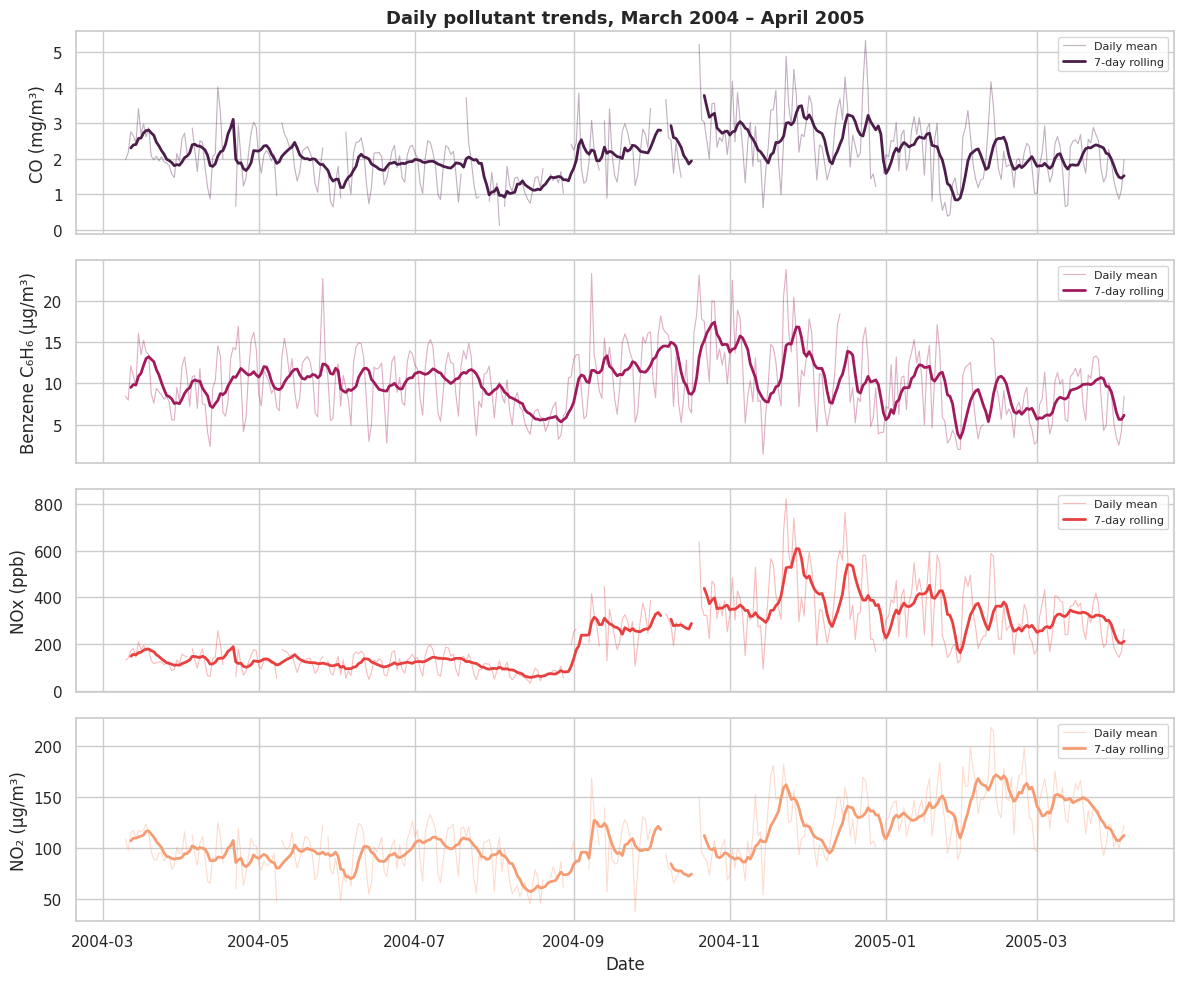

In [ ]:
PRETTY = {
    "CO_mgm3": "CO (mg/m³)", "C6H6_ugm3": "Benzene C₆H₆ (µg/m³)",
    "NOx_ppb": "NOx (ppb)", "NO2_ugm3": "NO₂ (µg/m³)",
}
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, col, c in zip(axes, POLLUTANTS, sns.color_palette("rocket", 4)):
    ax.plot(daily.index, daily[col], color=c, alpha=0.35, lw=0.8, label="Daily mean")
    ax.plot(daily.index, daily[col].rolling(7, min_periods=3).mean(),
            color=c, lw=2, label="7-day rolling")
    ax.set_ylabel(PRETTY[col]); ax.legend(fontsize=8)
axes[0].set_title("Daily pollutant trends, March 2004 – April 2005",
                  fontsize=13, fontweight="bold")
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()

**Observations:** NOx and NO₂ concentrations rise markedly from October onward, coinciding with cooler conditions. Seasonal changes in emissions and atmospheric dispersion may contribute to this pattern. CO and benzene decline during late summer. The dataset ends before a comparable 2005 summer trough can be observed.

## 6 · Diurnal cycle — the rush-hour fingerprint

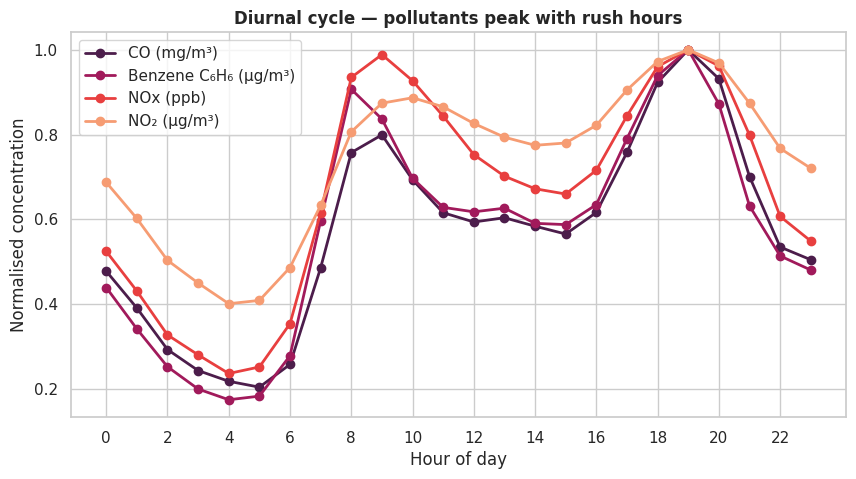

In [ ]:
hourly_profile = df_clean.groupby(df_clean.index.hour)[POLLUTANTS].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for col, c in zip(POLLUTANTS, sns.color_palette("rocket", 4)):
    s = hourly_profile[col] / hourly_profile[col].max()
    ax.plot(s.index, s.values, marker="o", lw=2, color=c, label=PRETTY[col])
ax.set(xticks=range(0, 24, 2), xlabel="Hour of day", ylabel="Normalised concentration")
ax.set_title("Diurnal cycle — hourly pollutant patterns",
             fontsize=12, fontweight="bold")
ax.legend(); plt.show()

## 7 · Correlation matrix

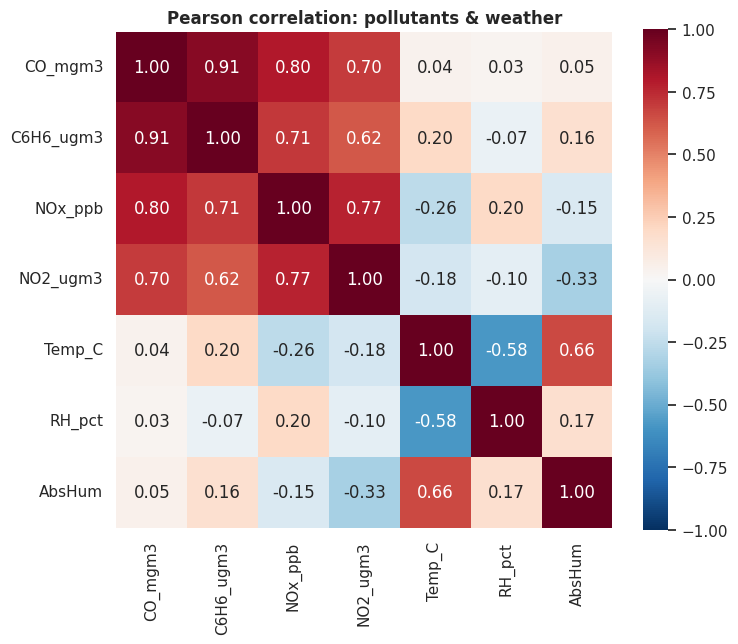

In [ ]:
corr = df_clean[POLLUTANTS + WEATHER].corr().round(2)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson correlation: pollutants & weather",
             fontsize=12, fontweight="bold")
plt.show()

**Three blocks pop out:**
1. **Combustion cluster** — CO, benzene, NOx, NO₂ all correlate r ≈ 0.6–0.9 → a pattern consistent with shared combustion-related sources, including road traffic.
2. **Weather** — Temperature and absolute humidity are positively correlated (r = 0.66), while temperature and relative humidity are negatively correlated (r = −0.58) over the observed period.
3. **Cross terms** — NOx and NO₂ show negative associations with temperature. Seasonal variation in emissions and atmospheric dispersion may contribute to these relationships.

## 8 · Weekday vs weekend

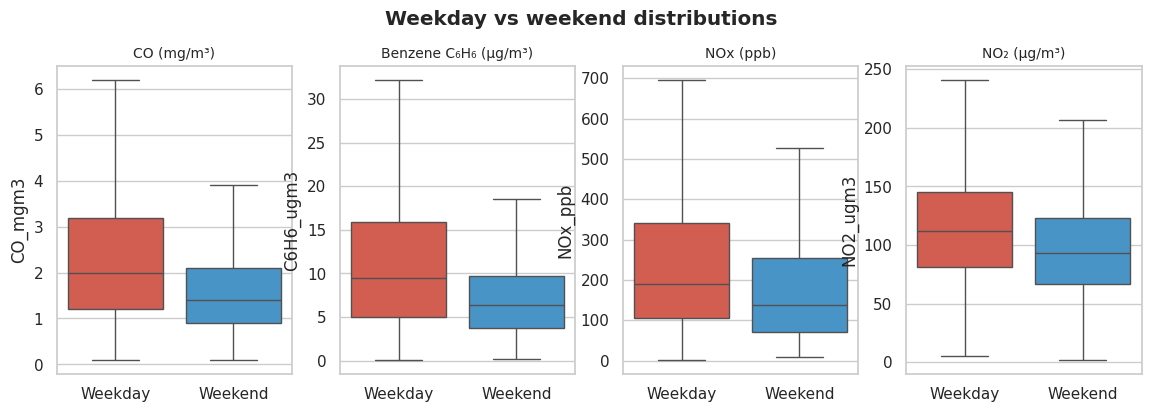

NOx mean — Weekday: 261 ppb · Weekend: 190 ppb · drop: 27%


In [ ]:
tmp = df_clean.copy()
tmp["DayType"] = np.where(tmp.index.dayofweek < 5, "Weekday", "Weekend")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, POLLUTANTS):
    sns.boxplot(data=tmp, x="DayType", y=col, ax=ax,
                palette=["#e74c3c", "#3498db"], showfliers=False)
    ax.set_title(PRETTY[col], fontsize=10); ax.set_xlabel("")
plt.suptitle("Weekday vs weekend distributions", fontweight="bold", y=1.02)
plt.show()

wd = tmp.loc[tmp["DayType"] == "Weekday", "NOx_ppb"].mean()
we = tmp.loc[tmp["DayType"] == "Weekend", "NOx_ppb"].mean()
print(f"NOx mean — Weekday: {wd:.0f} ppb · Weekend: {we:.0f} ppb · drop: {100*(wd-we)/wd:.0f}%")

## 9 · Predictive model — benzene

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

m = df_clean.dropna(subset=POLLUTANTS + WEATHER).copy()
m["hour"], m["dow"], m["month"] = m.index.hour, m.index.dayofweek, m.index.month
features = ["CO_mgm3", "NOx_ppb", "NO2_ugm3",
            "Temp_C", "RH_pct", "AbsHum", "hour", "dow", "month"]
target = "C6H6_ugm3"

X, y = m[features], m[target]
split = int(len(X) * 0.8)
X_tr, X_te, y_tr, y_te = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

results = []
for name, mdl in [("Linear Regression", LinearRegression()),
                  ("Random Forest", RandomForestRegressor(
                      n_estimators=120, random_state=0, n_jobs=-1))]:
    mdl.fit(X_tr, y_tr)
    pred = mdl.predict(X_te)
    results.append({"Model": name,
                    "MAE": round(mean_absolute_error(y_te, pred), 2),
                    "R²":  round(r2_score(y_te, pred), 2)})

pd.DataFrame(results)

,Model,MAE,R²
0,Linear Regression,2.26,0.77
1,Random Forest,1.76,0.77


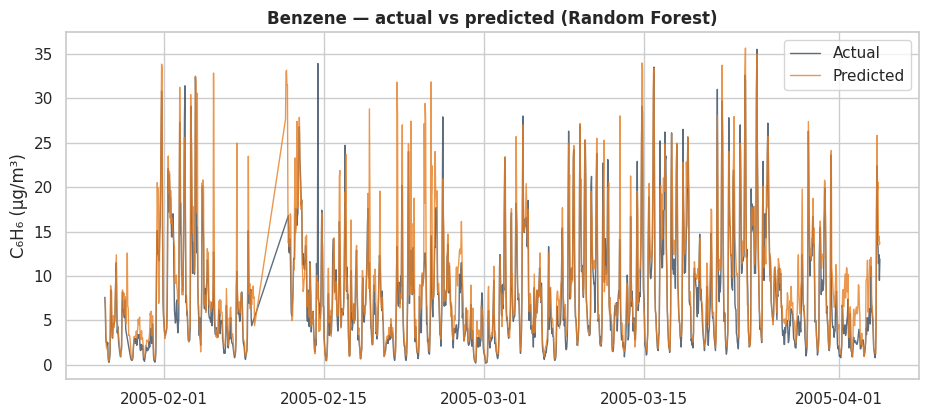

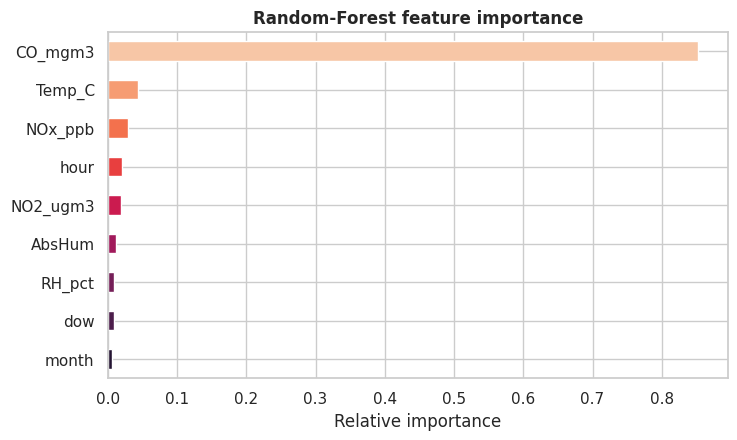

In [ ]:
rf = RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1).fit(X_tr, y_tr)
pred = rf.predict(X_te)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(m.index[split:], y_te.values, color="#34495e", lw=1, alpha=0.8, label="Actual")
ax.plot(m.index[split:], pred,        color="#e67e22", lw=1, alpha=0.8, label="Predicted")
ax.set_title("Benzene — actual vs predicted (Random Forest)", fontweight="bold")
ax.set_ylabel("C₆H₆ (µg/m³)"); ax.legend(); plt.show()

# Feature importance
fi = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
fi.plot(kind="barh", ax=ax, color=sns.color_palette("rocket", len(fi)))
ax.set_title("Random-Forest feature importance", fontweight="bold")
ax.set_xlabel("Relative importance"); plt.show()

## 10 · Conclusions

| Theme | Finding |
| --- | --- |
| **Sources** | CO, benzene, NOx and NO₂ form a strong combustion-related correlation cluster (r = 0.6–0.9), consistent with shared sources such as road traffic. |
| **Diurnal** | Twin peaks at 08:00 and 19:00; trough at 05:00; evening peak the larger of the two. |
| **Seasonal** | Winter peaks for NOx/NO₂; summer dip for CO/benzene. |
| **Weekly** | NOx is ~27 % lower at weekends, a pattern consistent with reduced traffic activity. |
| **Health** | Benzene is a carcinogenic air pollutant. The mean concentration in this dataset (~10.1 µg/m³) is approximately twice the EU calendar-year limit value of 5 µg/m³ and substantially above the 1.7 µg/m³ concentration WHO associates with an excess lifetime leukaemia risk of 1 in 100,000. This single-site dataset is not an individual exposure or lifetime-risk assessment. |
| **Modelling** | A Random Forest predicts hourly benzene at R² ≈ 0.77 from CO + NOx + NO₂ + weather + hour-of-day, showing that co-located pollutant and weather variables contain substantial predictive signal for benzene in this dataset. |

### Limitations
- Single site, 13 months — not enough for inter-annual trends or policy-impact assessment.
- NMHC dropped (>90 % missing).
- Correlation does not equal causation; weather and traffic seasonality are confounded.